In [1]:
%pip install arm-pyart s3fs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.8/157.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 2.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully

In [ ]:
# Cell removed: pip install ipympl

In [ ]:
# Cell removed: %matplotlib widget

In [11]:
import gzip, io
import fsspec, pyart
import matplotlib.pyplot as plt

# --- 1. connect to the public NEXRAD archive (anonymous) ---
fs = fsspec.filesystem("s3", anon=True)

# Choose block
block = 3

match block:
    case 1:
        # Block 1
        folder = "unidata-nexrad-level2/2006/03/11/KNKX/"
    case 2:
        # Block 2
        folder = "unidata-nexrad-level2/2013/05/20/KTLX/"
        #folder = "unidata-nexrad-level2/2013/05/20/KINX/"
    case 3:
        # Block 3
        folder = "unidata-nexrad-level2/2003/09/18/KAKQ/"
    case 4:
        # Block 4
        folder = "unidata-nexrad-level2/2006/03/11/KNKX/"

# --- 2. (optional) browse the folder to pick a volume ---
for f in fs.ls(folder):
    print(f.split("/")[-1])


KAKQ20030918_000429.gz
KAKQ20030918_001018.gz
KAKQ20030918_001607.gz
KAKQ20030918_002156.gz
KAKQ20030918_002746.gz
KAKQ20030918_003334.gz
KAKQ20030918_004027.gz
KAKQ20030918_004616.gz
KAKQ20030918_005206.gz
KAKQ20030918_005754.gz
KAKQ20030918_010342.gz
KAKQ20030918_010931.gz
KAKQ20030918_011520.gz
KAKQ20030918_012109.gz
KAKQ20030918_012657.gz
KAKQ20030918_013247.gz
KAKQ20030918_013835.gz
KAKQ20030918_014424.gz
KAKQ20030918_015014.gz
KAKQ20030918_015602.gz
KAKQ20030918_020151.gz
KAKQ20030918_020740.gz
KAKQ20030918_021329.gz
KAKQ20030918_021919.gz
KAKQ20030918_022507.gz
KAKQ20030918_023055.gz
KAKQ20030918_023644.gz
KAKQ20030918_024233.gz
KAKQ20030918_024822.gz
KAKQ20030918_025411.gz
KAKQ20030918_025959.gz
KAKQ20030918_030547.gz
KAKQ20030918_031137.gz
KAKQ20030918_031725.gz
KAKQ20030918_032314.gz
KAKQ20030918_032902.gz
KAKQ20030918_033451.gz
KAKQ20030918_034039.gz
KAKQ20030918_034629.gz
KAKQ20030918_035217.gz
KAKQ20030918_035807.gz
KAKQ20030918_040357.gz
KAKQ20030918_040945.gz
KAKQ2003091

In [18]:
import numpy as np

# --- read radar ---
match block:
    case 1:
        key = folder + "KNKX20060311_222506.gz"
    case 2:
        key = folder + "KTLX20130520_201643_V06.gz"
        #key = folder + "KINX20130520_201750_V06.gz"
    case 3:
        key = folder + "KAKQ20030918_234511.gz"
    case 4:
        key = folder + "KNKX20060311_222506.gz"

with fs.open(key, "rb") as fh:
    raw = fh.read()

if raw[:2] == b"\x1f\x8b":
    raw = gzip.decompress(raw)

radar = pyart.io.read_nexrad_archive(io.BytesIO(raw))

In [13]:
print(radar.fixed_angle["data"])

[ 0.5  0.5  1.4  1.5  2.3  3.3  4.1  5.2  6.2  7.5  8.6  9.8 12.  13.8
 16.7 19.4]


In [20]:
product = "reflectivity"
#product = "velocity"

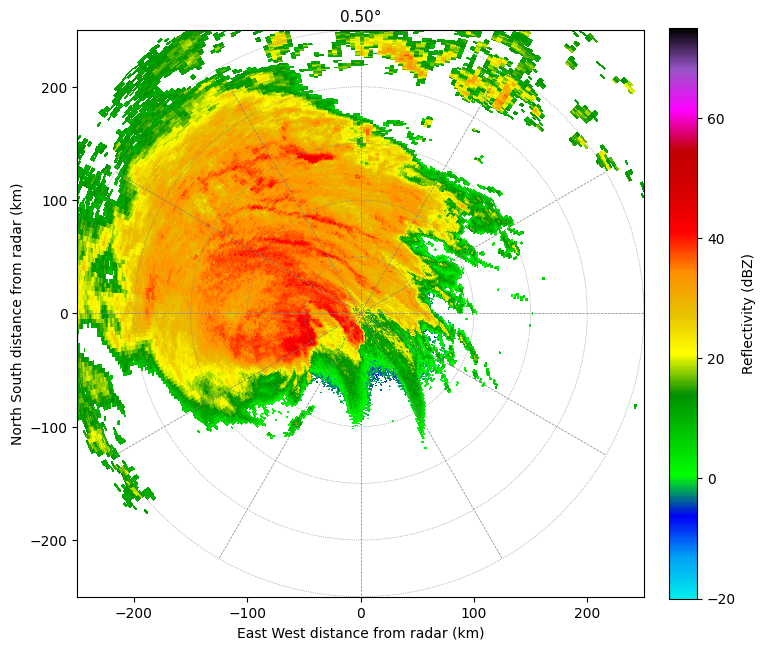

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pyart

max_range = 250

# reflectivity lives on sweep 0, velocity on sweep 1
sweep = 0 if product == "reflectivity" else 1

fig, ax = plt.subplots(figsize=(8, 8))
disp = pyart.graph.RadarDisplay(radar)

if product == "reflectivity":
    disp.plot_ppi(product, sweep=sweep, vmin=-20, vmax=75,
              cmap="NWSRef", colorbar_flag=False, ax=ax)
else:
    disp.plot_ppi(product, sweep=sweep, vmin=-35, vmax=35,
                  cmap="NWSVel", colorbar_flag=False, ax=ax)

disp.set_limits(xlim=(-max_range, max_range),
                ylim=(-max_range, max_range), ax=ax)
ax.set_aspect("equal")

# range rings every 50 km, out to the displayed range
rings = list(range(50, int(max_range) + 1, 50))
disp.plot_range_rings(rings, col="gray", lw=0.5, ls="dotted")

# azimuth spokes every 30°
for az in range(0, 360, 30):
    theta = np.deg2rad(az)
    ax.plot([0, max_range * np.sin(theta)],
            [0, max_range * np.cos(theta)],
            color="gray", lw=0.5, ls="dashed")

angle = radar.fixed_angle["data"][sweep]
ax.set_title(f"{angle:.2f}°", fontsize=11)

# color bar
cbar = plt.colorbar(disp.plots[-1], ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Reflectivity (dBZ)")

# save figure
plt.savefig("image.png", dpi=80, bbox_inches="tight")
plt.show()

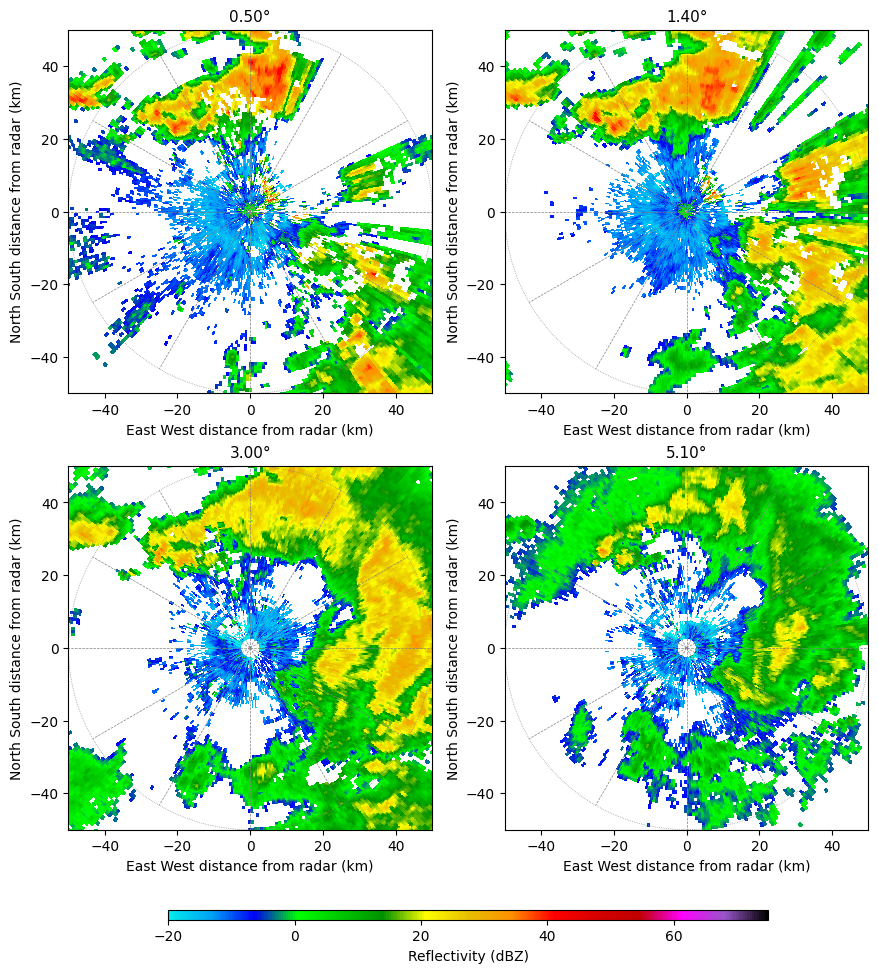

In [ ]:
# --- figure setup (more compact) ---
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

disp = pyart.graph.RadarDisplay(radar)
max_range = 250

if product == "reflectivity":
  sweeps = 0, 4, 8, 10
else:
  sweeps = 1, 5, 8, 10

for i in range(4):
    ax = axes[i]
    plt.sca(ax)

    if product == "reflectivity":
        disp.plot_ppi(
            product,
            sweep=sweeps[i],
            vmin=-20,
            vmax=75,
            cmap="NWSRef",
            colorbar_flag=False
        )
    else:
        disp.plot_ppi(
            product,
            sweep=sweeps[i],
            vmin=-35,
            vmax=35,
            cmap="NWSVel",
            colorbar_flag=False
        )

    disp.set_limits(xlim=(-max_range, max_range),
                    ylim=(-max_range, max_range))

    # range rings
    disp.plot_range_rings(
        [50, 100, 150, 200, 250, 300, 350, 400],
        col="gray", lw=0.5, ls="dotted"
    )

    # azimuth spokes
    for az in range(0, 360, 30):
        theta = np.deg2rad(az)
        x = [0, max_range * np.sin(theta)]
        y = [0, max_range * np.cos(theta)]
        ax.plot(x, y, color="gray", lw=0.5, ls="dashed")

    # title
    angle = radar.fixed_angle["data"][sweeps[i]]
    ax.set_title(f"{angle:.2f}°", fontsize=11)

# --- MANUAL spacing (prevents overlap) ---
plt.subplots_adjust(
    left=0.1, right=0.9,
    top=0.9, bottom=0.1,
    wspace=0.2, hspace=0.2
)

# --- dedicated colorbar axis (below plots) ---
cax = fig.add_axes([0.2, 0.01, 0.6, 0.01])  # [left, bottom, width, height]

cbar = plt.colorbar(disp.plots[0], cax=cax, orientation="horizontal")
if product == "reflectivity":
    cbar.set_label("Reflectivity (dBZ)")
else:
    cbar.set_label("Velocity (m/s)")


plt.savefig("image.png", dpi=80)
plt.show()

